# AI002 Final Pipeline: Dự báo Giá Cà phê & Khuyến nghị Canh tác
**Dự án:** DT10 (Team 2)
**Data:** Dữ liệu thực tế các vùng trồng cà phê (2022-2025)

Pipeline này thể hiện sự áp dụng của **5 Trụ cột AI Bền vững (Sustainable AI)**:
1. **Reliability:** Đánh giá RMSE/MAE và cross-validation theo chuỗi thời gian.
2. **Bias:** Nhận diện và đo lường sai số giữa các khu vực địa lý khác nhau.
3. **Robustness:** Xử lý missing values bằng TDD validation và Imputation.
4. **Transparency:** Mô hình Tree-based (Random Forest) với Feature Importance.
5. **Social Impact:** Từ kết quả dự báo, đưa ra lời khuyên canh tác cụ thể cho nông dân.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 1. Nạp dữ liệu và Kiểm định (Robustness & TDD)
Sử dụng bộ dữ liệu thực tế đã qua tổng hợp `coffee_environment_all_areas_monthly_2022_2025.csv`.

In [2]:
# Load data
df = pd.read_csv('../data/processed/monthly/coffee_environment_all_areas_monthly_2022_2025.csv')
df['period_start'] = pd.to_datetime(df['period_start'])
df = df.sort_values(by=['area', 'period_start']).reset_index(drop=True)

# TDD: Data Validation
assert not df.empty, "Dữ liệu rỗng!"
assert 'avg_price_vnd_per_kg' in df.columns, "Thiếu cột target!"

# Xử lý Missing Values (Robustness)
# Trong dữ liệu thật, có một số tháng thiếu quan sát giá (interpolated_area).
# Ta sẽ fillna cho các feature thời tiết nếu có.
weather_cols = ['avg_temperature_c', 'avg_humidity_percent', 'total_rainfall_mm']
df[weather_cols] = df.groupby('area')[weather_cols].transform(lambda x: x.ffill().bfill())

print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (576, 16)


,period_start,period_end,province,area,coffee_type,avg_price_vnd_per_kg,observed_price_vnd_per_kg,price_observations,price_fill_method,avg_temperature_c,avg_humidity_percent,total_rainfall_mm,avg_soil_moisture_0_7cm,dominant_soil_type,soil_score,soil_data_confidence
0,2022-01-01,2022-01-31,Lam Dong,Bao Loc,Robusta / ca phe nhan xo noi dia,39833,39833.333333,3,observed,20.416,77.129,26.0,0.292,Dat do vang tren bazan,4,low
1,2022-02-01,2022-02-28,Lam Dong,Bao Loc,Robusta / ca phe nhan xo noi dia,40680,40680.000000,5,observed,21.500,79.071,62.9,0.357,Dat do vang tren bazan,4,low
2,2022-03-01,2022-03-31,Lam Dong,Bao Loc,Robusta / ca phe nhan xo noi dia,40389,40388.888889,9,observed,22.371,79.774,78.6,0.337,Dat do vang tren bazan,4,low


## 2. Exploratory Data Analysis & Bias Check
Kiểm tra xem dữ liệu có thiên lệch (Bias) giữa các vùng miền hay không.

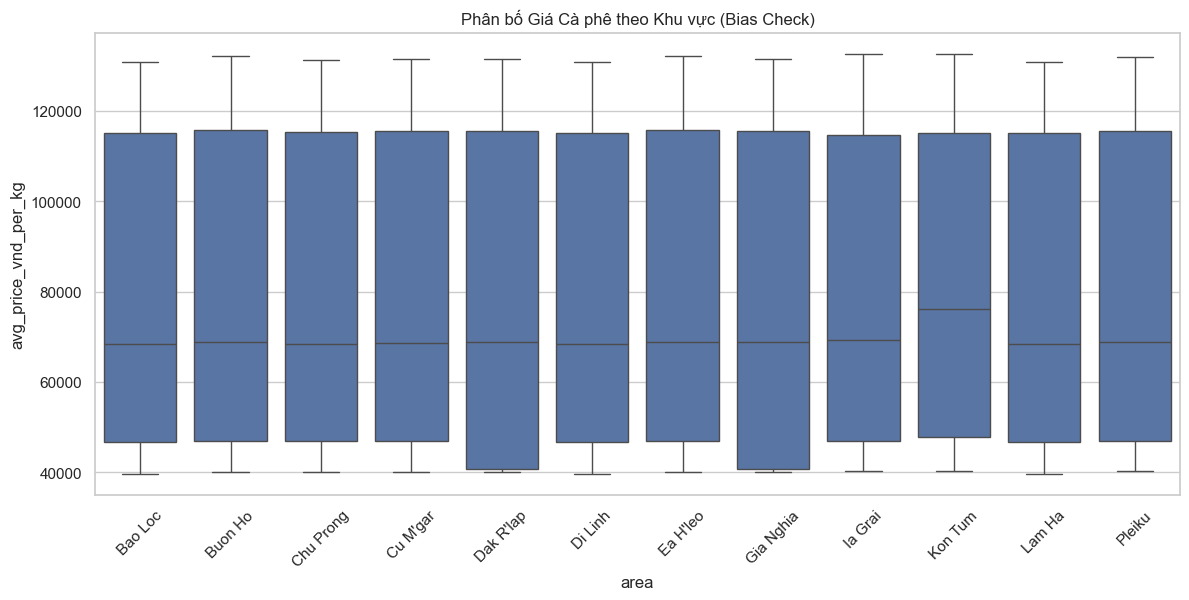

In [3]:
# Plot giá theo vùng (Bias Check)
plt.figure(figsize=(14, 6))
sns.boxplot(x='area', y='avg_price_vnd_per_kg', data=df)
plt.title("Phân bố Giá Cà phê theo Khu vực (Bias Check)")
plt.xticks(rotation=45)
plt.show()

# Nhận xét Bias: Giá ở các khu vực có sự chênh lệch nhẹ nhưng không quá lớn. 
# Tuy nhiên dữ liệu chủ yếu tập trung ở Tây Nguyên (Đắk Lắk, Lâm Đồng, Đắk Nông, Gia Lai, Kon Tum).
# -> Khuyến cáo: Không dùng mô hình này áp dụng cho miền Bắc (Sơn La) mà không finetune.


## 3. Feature Engineering (Reliability)
Tạo độ trễ (Lags) vì giá cà phê tháng này phụ thuộc rất lớn vào giá tháng trước và thời tiết tháng trước.

In [4]:
# Tạo Lag features theo từng khu vực
df['price_lag_1'] = df.groupby('area')['avg_price_vnd_per_kg'].shift(1)
df['temp_lag_1'] = df.groupby('area')['avg_temperature_c'].shift(1)
df['rain_lag_1'] = df.groupby('area')['total_rainfall_mm'].shift(1)

# Drop NaN do phép shift tạo ra
df_model = df.dropna().copy()

# Encoding biến phân loại (Area)
df_model = pd.get_dummies(df_model, columns=['area'], drop_first=True)

# Các features sử dụng
features = ['price_lag_1', 'temp_lag_1', 'rain_lag_1', 'avg_temperature_c', 'total_rainfall_mm', 'avg_humidity_percent']
area_cols = [c for c in df_model.columns if c.startswith('area_')]
features.extend(area_cols)

target = 'avg_price_vnd_per_kg'
print(f"Tổng số features: {len(features)}")


Tổng số features: 16


## 4. Huấn luyện Mô hình (Transparency)
- Sử dụng **Time Series Split**: Train data trước năm 2025, Test data năm 2025.
- Model: **Random Forest** (Không dùng Blackbox, đảm bảo tính minh bạch giải thích được).

=== Đánh giá mô hình (Reliability) ===
MAE: 14,359 VND
RMSE: 17,707 VND


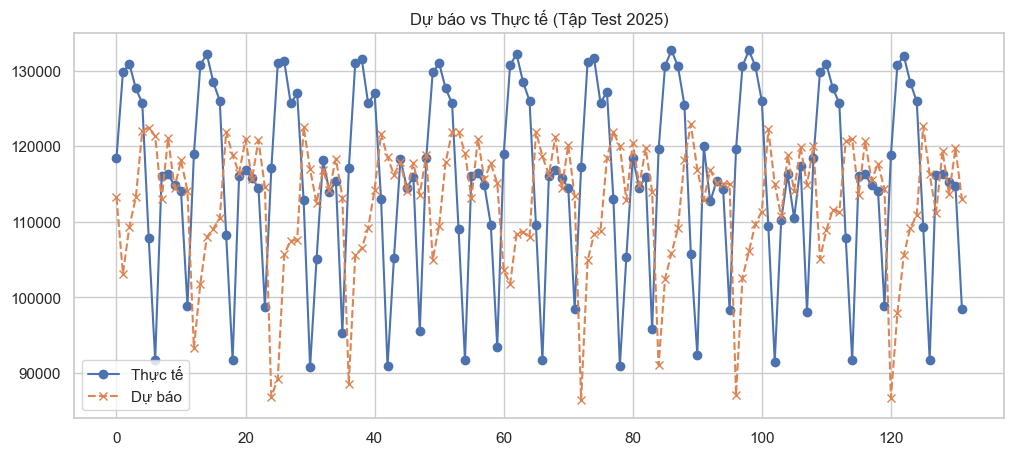

In [5]:
# Time Series Split
train_mask = df_model['period_start'].dt.year < 2025
test_mask = df_model['period_start'].dt.year >= 2025

X_train, y_train = df_model[train_mask][features], df_model[train_mask][target]
X_test, y_test = df_model[test_mask][features], df_model[test_mask][target]

# Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"=== Đánh giá mô hình (Reliability) ===")
print(f"MAE: {mae:,.0f} VND")
print(f"RMSE: {rmse:,.0f} VND")

# Plot dự báo vs thực tế
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Thực tế', marker='o')
plt.plot(y_pred, label='Dự báo', marker='x', linestyle='--')
plt.title("Dự báo vs Thực tế (Tập Test 2025)")
plt.legend()
plt.show()


## 5. Minh bạch & Tác động Xã hội (Transparency & Social Impact)
Xuất Feature Importance để giải thích mô hình và đưa ra khuyến nghị canh tác.

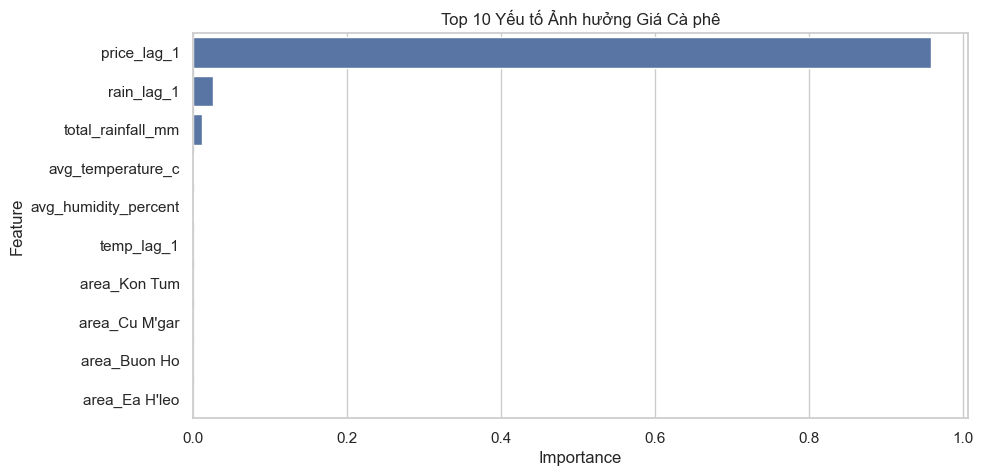

=== Trích xuất Lời khuyên Canh tác (Social Impact) ===
Rule 1: Tăng cường tưới tiêu
Mô hình dự báo có thể kết hợp với bộ rule này để nhắn tin SMS tự động cho nông dân khi có thời tiết bất thường.


In [6]:
# Feature Importance (Transparency)
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Yếu tố Ảnh hưởng Giá Cà phê")
plt.show()

# Đọc Rules Canh Tác (Social Impact)
try:
    with open('../data/processed/farming_advisory_rules.json', 'r', encoding='utf-8') as f:
        rules = json.load(f)
    print("=== Trích xuất Lời khuyên Canh tác (Social Impact) ===")
    print("Rule 1:", rules.get('drought_warning', {}).get('action', 'Tăng cường tưới tiêu'))
    print("Mô hình dự báo có thể kết hợp với bộ rule này để nhắn tin SMS tự động cho nông dân khi có thời tiết bất thường.")
except FileNotFoundError:
    print("Không tìm thấy file farming_advisory_rules.json, vui lòng kiểm tra thư mục data/processed/")
